In [ ]:
# The goal is to train a classifier that can predict the `Survived` column based on the other columns._
# first try was in ch2/try-it-out/main.ipynb

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
from sklearn.model_selection import train_test_split

file_path = "./Titanic-Dataset.csv"
titanic_full: pd.DataFrame = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
  file_path,
)

train_data, test_data = train_test_split(
    titanic_full, test_size=0.2, stratify=titanic_full["Pclass"], random_state=42
)

train_data = train_data
test_data = test_data

train_data.info()



<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 820 to 144
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    object 
 4   Sex          712 non-null    object 
 5   Age          574 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    object 
 9   Fare         712 non-null    float64
 10  Cabin        161 non-null    object 
 11  Embarked     710 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.3+ KB


In [115]:
# Feature engineering

def isSoloTraveler(data_split):
	return ((data_split["SibSp"] == 0) & (data_split["Parch"] == 0)).astype(int)

def createCabinMark(data_split):
	# Fill all like {}
	result = pd.Series([set()] * len(data_split), index=data_split.index)
	condition = (data_split["Cabin"].notnull())
	filtered = data_split[condition]["Cabin"]
	formatted = filtered.str.split(" ")
	# Fill only not null
	result.loc[condition] = formatted.apply(
        lambda x: set(item[0] for item in x)
    )
	return result


train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"]
test_data["FamilySize"] = test_data["SibSp"] + test_data["Parch"]

train_data["AgeBucket"] = train_data["Age"] // 15 * 15
test_data["AgeBucket"] = test_data["Age"] // 15 * 15

train_data["SoloTraveler"] = isSoloTraveler(train_data)
test_data["SoloTraveler"] = isSoloTraveler(test_data)

train_data["CabinMark"] = createCabinMark(train_data)
test_data["CabinMark"] = createCabinMark(test_data)

train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 820 to 144
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   712 non-null    int64  
 1   Survived      712 non-null    int64  
 2   Pclass        712 non-null    int64  
 3   Name          712 non-null    object 
 4   Sex           712 non-null    object 
 5   Age           574 non-null    float64
 6   SibSp         712 non-null    int64  
 7   Parch         712 non-null    int64  
 8   Ticket        712 non-null    object 
 9   Fare          712 non-null    float64
 10  Cabin         161 non-null    object 
 11  Embarked      710 non-null    object 
 12  FamilySize    712 non-null    int64  
 13  AgeBucket     574 non-null    float64
 14  SoloTraveler  712 non-null    int32  
 15  CabinMark     712 non-null    object 
dtypes: float64(3), int32(1), int64(6), object(6)
memory usage: 107.9+ KB


In [ ]:
# Custom Transformers

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer

# MultiLabelBinarizer.fit_transform() takes 2 positional arguments but 3 were given
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X.iloc[:, 0])
        return self

    def transform(self, X):
        return self.mlb.transform(X.iloc[:, 0])
    
    def get_feature_names_out(self, input_features=None):
        return self.mlb.classes_

In [119]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import numpy as np

num_pipeline = Pipeline([
	("imputer", SimpleImputer(strategy="median")),
])

num_freq_and_cat_encode = Pipeline([
	("freq_imputer", SimpleImputer(strategy="most_frequent")),
	("cat_encoder", OneHotEncoder())
])

cat_pipeline = Pipeline([
    ("ordinal_encoder", OrdinalEncoder()),                    # текст → число: female=0, male=1
    ("imputer", SimpleImputer(strategy="most_frequent")),     # заполняем пропуски самым частым значением
    ("cat_encoder", OneHotEncoder(sparse_output=False)),      # число → отдельные колонки: female=[1,0], male=[0,1]
])

multi_label_cat_pipeline = Pipeline([
	("multi_bin_cat", MultiLabelBinarizerTransformer())
])

num_scaler = Pipeline([
	# Оригинал условно 0, 7, 14, 512; после log1p: 0, 2.1, 2.7, 6.2; После std: -0.8, -0.2, 0.1, 1.9
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),  
    ("scaler", StandardScaler()), 
])

preprocess_pipeline = ColumnTransformer([
        ("num", num_pipeline, ["FamilySize"]),
		("num_freq", num_freq_and_cat_encode, ["Embarked", "AgeBucket"]),
		("ord_cat", cat_pipeline, ["Sex", "Pclass"]),
		("multi_cat", multi_label_cat_pipeline, ["CabinMark"]),
		("num_scaler", num_scaler, ["Fare"]),
		# passthrough оставь как есть, там преобразования не нужны, уже проставленны 0 и 1
		("solo", "passthrough", ["SoloTraveler"]),
    ])

# Преобразовываем данные
X_train = preprocess_pipeline.fit_transform(train_data)
# Получаем лейблы
y_train = train_data["Survived"]

# Отображение
cols = preprocess_pipeline.get_feature_names_out()
pd.DataFrame(X_train, columns=cols).info() # Return to Dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   num__FamilySize           712 non-null    float64
 1   num_freq__Embarked_C      712 non-null    float64
 2   num_freq__Embarked_Q      712 non-null    float64
 3   num_freq__Embarked_S      712 non-null    float64
 4   num_freq__AgeBucket_0.0   712 non-null    float64
 5   num_freq__AgeBucket_15.0  712 non-null    float64
 6   num_freq__AgeBucket_30.0  712 non-null    float64
 7   num_freq__AgeBucket_45.0  712 non-null    float64
 8   num_freq__AgeBucket_60.0  712 non-null    float64
 9   num_freq__AgeBucket_75.0  712 non-null    float64
 10  ord_cat__Sex_0.0          712 non-null    float64
 11  ord_cat__Sex_1.0          712 non-null    float64
 12  ord_cat__Pclass_0.0       712 non-null    float64
 13  ord_cat__Pclass_1.0       712 non-null    float64
 14  ord_cat__P

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
logistic_scores = cross_val_score(model, X_train, y_train,
    scoring="accuracy", cv=10)

# 1) 0.786541
# 2) "Pclass" и  "SibSp", "Parch"  0.799257
# 3) FamilySize 0.803443
# 4) AgeBucket 0.804812
# 5) SoloTraveler 0.803384
# 6) MultiLabel Cabin 0.816041
pd.Series(logistic_scores).describe()

count    10.000000
mean      0.816041
std       0.048345
min       0.718310
25%       0.792254
50%       0.816901
75%       0.852700
max       0.887324
dtype: float64

In [ ]:
# Автор книги сразу перешел к RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
forest_clf.fit(X_train, y_train)
forest_scores = cross_val_score(forest_clf, X_train, y_train, cv=10)
# 1) 0.7794992175273865
# 2) "Pclass" и  "SibSp", "Parch" 0.8174100156494521
# 3) FamilySize  0.8174491392801253
# 4) AgeBucket 0.8272691705790297
# 5) SoloTraveler 0.8216549295774648
# 6) MultiLabel Cabin 0.8160406885758998
forest_scores.mean()

0.8160406885758998

In [ ]:
# также автор предлагал после этого попробовать SVC
from sklearn.svm import SVC

svm_clf = SVC(gamma="auto")
svm_scores = cross_val_score(svm_clf, X_train, y_train, cv=10)
# 1) 0.77533255086072
# 2)  "Pclass" и  "SibSp", "Parch"] 0.8258802816901408
# 3) FamilySize 0.820266040688576
# 4) AgeBucke 0.8356611893583725
# 5) SoloTraveler 0.8314358372456964
# 6) MultiLabel Cabin 0.8173708920187792
svm_scores.mean()

0.8173708920187792

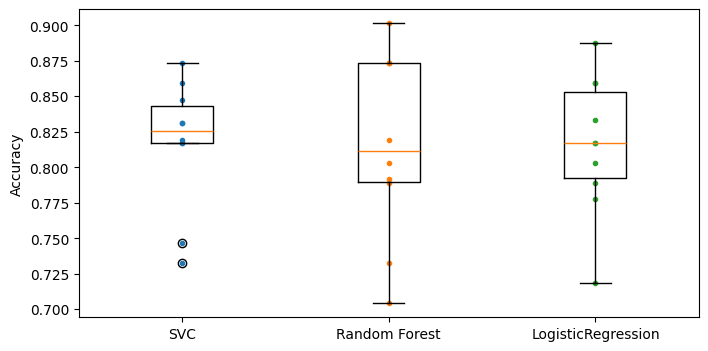

In [124]:
import matplotlib.pyplot as plt

# Вместо того чтобы просто смотреть среднюю точность по 10 фолдам кросс валидации
# Можно построить график 10 результатов каждой модели и также добавим boxplot
# Box plot показывает не только среднее качество модели, но и её стабильность.
# Например, если две модели имеют accuracy 0.82 в среднем, но:
# у первой результаты по фолдам: 0.81–0.83,
#  у второй: 0.70–0.94,
# то среднее одинаковое, но первая модель гораздо стабильнее. 
# Box plot позволяет увидеть такой разброс и возможные выбросы.
  

plt.figure(figsize=(8, 4))
plt.plot([1]*10, svm_scores, ".")
plt.plot([2]*10, forest_scores, ".")
plt.plot([3]*10, logistic_scores, ".")
# boxplot - автоматически определяет выбросы (outliers, или fliers) и не включает их в длину усов.
plt.boxplot([svm_scores, forest_scores, logistic_scores], labels=("SVC", "Random Forest", "LogisticRegression"))
plt.ylabel("Accuracy")
plt.show()
# Random Forest показывает чуть более 
# высокую точность и более стабильные результаты на кросс-валидации, чем SVC.
# Logistic Regression медиана немного ниже, чем у Random Forest (~0.82); разброс больше

# После FamilySize разбросы стали больше и уже сложнее сказать было что лучше

# Но после AgeBucket явно видно что SVM лучше


In [ ]:
# Пробуй подбор лучших гиперпараметров для RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
param_grid = {'n_estimators': [50, 100, 150],
              'max_depth': [10, 20, 30]}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)
grid_search.fit(X_train,y_train)

print(f'Best Params: {grid_search.best_params_}')
print(f'Best Score: {grid_search.best_score_}')

# 2) 0.83 
# 3) 0.82
# 4) 0.8286023835319609
# 5) SoloTraveler 0.824386880724909
# 6) MultiLabel Cabin 0.8314389835516597

Best Params: {'max_depth': 10, 'n_estimators': 100}
Best Score: 0.8314389835516597


In [ ]:
# Пробуй подбор лучших гиперпараметров для SVC

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svc = SVC()

param_grid = [
    # {"kernel": ["linear"], "C": [0.1, 1, 10]},
    {"kernel": ["rbf"], "C": [0.1, 1, 10], "gamma": [0.001, 0.01, 0.1]},
]

grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=5,
    n_jobs=1
)
grid_search.fit(X_train, y_train)

print("最適なパラメータ:", grid_search.best_params_)
print("最高のスコア:", grid_search.best_score_)

# 2) 0.8229685807150597
# 3) 0.8257854821235103
# 4) 0.8426277947404708
# 5) SoloTraveler 0.8426277947404708
# 6) MultiLabel Cabin 0.8468531468531468

最適なパラメータ: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
最高のスコア: 0.8468531468531468
